<a href="https://colab.research.google.com/github/Anodyne-eng/Anodyne-eng/blob/main/Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("\nDataFrame Info:")
df.info()

missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


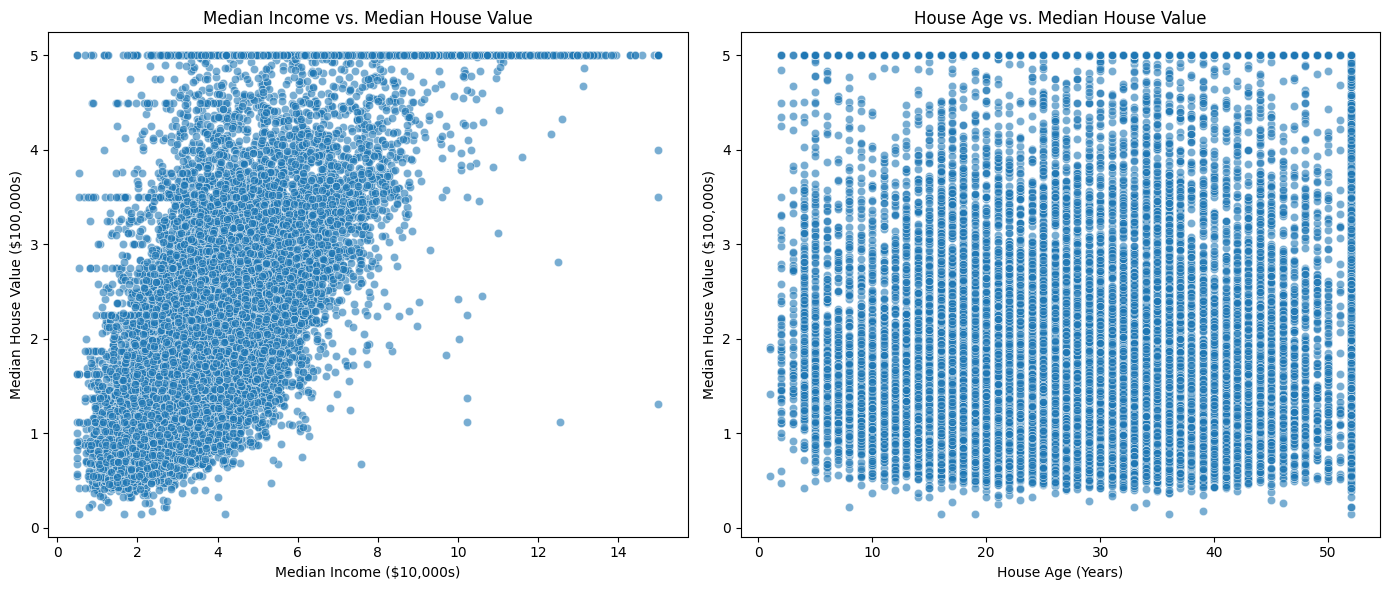

In [ ]:
plt.figure(figsize=(14, 6)) # Set the overall figure size for two plots side-by-side.

# --- First Subplot: Median Income vs. Median House Value ---
plt.subplot(1, 2, 1) # Create a grid of 1 row, 2 columns, and select the 1st plot for the next command.
# `sns.scatterplot` is a Seaborn function for scatter plots.
# `x='MedInc'`, `y='MedHouseVal'`: Specifies which columns map to the x and y axes.
# `data=df`: Indicates which DataFrame to use.
# `alpha=0.6`: Makes the points semi-transparent, useful when many points overlap, to show density.
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df, alpha=0.6)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')

# --- Second Subplot: House Age vs. Median House Value ---
plt.subplot(1, 2, 2) # Select the 2nd plot in our 1x2 grid.
sns.scatterplot(x='HouseAge', y='MedHouseVal', data=df, alpha=0.6)
plt.title('House Age vs. Median House Value')
plt.xlabel('House Age (Years)')
plt.ylabel('Median House Value ($100,000s)')

plt.tight_layout() # Automatically adjusts plot parameters for a tight layout, preventing labels from overlapping.
plt.show()

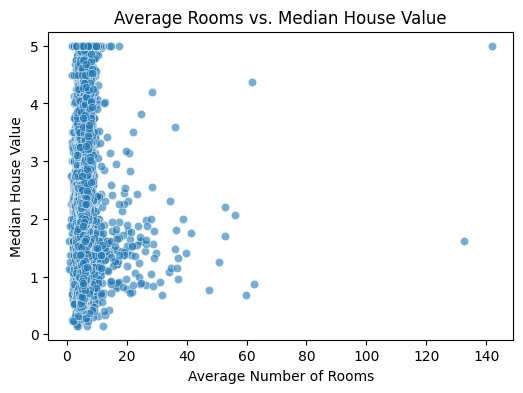

In [ ]:
#Relationship between Average Rooms and MedHouseVal
plt.figure(figsize=(6, 4))
sns.scatterplot(x='AveRooms', y='MedHouseVal', data=df, alpha=0.6)
plt.title('Average Rooms vs. Median House Value')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value')
plt.show()


In [ ]:
# Preparing the data for Machine Learning
# Split into features and lables
# X is for features and y is for labels
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
X = df[features]
y = df['MedHouseVal']
print(f"Selected features(X):\n{X.head()}")
print(f"\nSelected lable (y): \n{y.head()}")

# Split into testing set and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\nOriginal set size: {len(df)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Selected features(X):
   MedInc  HouseAge  AveRooms  Population
0  8.3252      41.0  6.984127       322.0
1  8.3014      21.0  6.238137      2401.0
2  7.2574      52.0  8.288136       496.0
3  5.6431      52.0  5.817352       558.0
4  3.8462      52.0  6.281853       565.0

Selected lable (y): 
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Original set size: 20640
Training set size: 14448
Testing set size: 6192


In [ ]:
# Training the multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# comparing the predictions with the actual values
comparison_df = pd.DataFrame({'Actual Value:': y_test, 'Predicted Value:': y_pred})
display(comparison_df.head(11))

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"\nMean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")



,Actual Value:,Predicted Value:
20046,0.47700,1.065472
3024,0.45800,1.512815
15663,5.00001,2.337118
20484,2.18600,2.677742
9814,2.78000,2.086774
13311,1.58700,2.177592
7113,1.98200,2.694771
7668,1.57500,2.153277
18246,3.40000,2.074168
5723,4.46600,4.182155



Mean Absolute Error: 0.60
Mean Squared Error: 0.64
Root Mean Squared Error: 0.80
R-squared: 0.51


In [ ]:
# Mini challenge : Building a Regression model for Boston housing dataset
# The original Boston Housing dataset (`load_boston`) has been deprecated in scikit-learn v1.2 due to ethical concerns.
try:
  from sklearn.datasets import load_boston
  boston = load_boston()
  boston_df = pd.DataFrame(boston.data, columns=boston.feature_names)
  boston_df['MEDV'] = boston.target
  print("Boston housing dataset loaded successfully")
except ImportError:
  print("load_Boston is deprecated. Generating a synthetic regression dataset.")
  from sklearn.datasets import make_regression
  X_synth, y_synth = make_regression(n_samples=1000, n_features=13, n_informative=7, noise=15, random_state=42)
  boston_df = pd.DataFrame(X_synth, columns=[f"Feature_{i+1}" for i in range(X_synth.shape[1])])
  boston_df['MEDV'] = y_synth
  print("Synthetic regeression dataset generated")

print("\nFirst 5 rows of the dataset:")
display(boston_df.head())
print("\nDescriptive statistics of the dataset:")
print(boston_df.describe())

X_challenge = boston_df.drop(columns=['MEDV'])
y_challenge = boston_df['MEDV']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_challenge, y_challenge, test_size=0.25, random_state=42)

print(f"\nTraining set size: {len(X_train_c)} samples")
print(f"Testing set size: {len(X_test_c)} samples")

#Training the model
model_c = LinearRegression()
model_c.fit(X_train_c, y_train_c)
print("Model trained successfully")

#Making Predictions
y_pred_c = model_c.predict(X_test_c)

# Evaluations
mae_c = mean_absolute_error(y_test_c, y_pred_c)
mse_c = mean_squared_error(y_test_c, y_pred_c)
rmse_c = np.sqrt(mse_c)
r2_c = r2_score(y_test_c, y_pred_c)

print(f"\n--- Challenge Model Performance (Predicting MEDV) ---")
print(f"Mean Absolute Error (MAE): {mae_c:.2f}")
print(f"Mean Squared Error (MSE): {mse_c:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_c:.2f}")
print(f"R-squared (R²): {r2_c:.2f}")

coeff_df = pd.DataFrame({'Feature': X_challenge.columns, 'Coefficient':model_c.coef_})
print("\nChallenge Model Coefficients:")
display(coeff_df)

print(coeff_df.sort_values(by='Coefficient', ascending=False))





load_Boston is deprecated. Generating a synthetic regression dataset.
Synthetic regeression dataset generated

First 5 rows of the dataset:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,MEDV
0,-0.443044,0.941311,1.699957,0.463185,1.071543,0.190636,0.311309,-1.032524,0.697903,0.296576,1.403370,-0.479493,0.197292,159.082954
1,-0.223463,-1.245739,-0.446515,-0.072829,0.856399,0.214094,-1.514847,0.173181,0.482472,0.473238,-1.070892,0.714000,-0.846794,-130.174073
2,-1.375149,0.642717,-0.284510,0.356668,-2.523457,-0.300935,-1.329359,0.720639,-0.663338,-1.410802,-0.812169,0.203482,2.236971,-152.398163
3,1.052547,1.202249,1.213179,0.886579,0.532892,-0.617286,-0.924268,1.206536,-1.704776,0.247271,-1.120897,-1.842937,-1.451226,-198.747107
4,0.763903,-0.280111,0.825415,-1.041453,-1.726214,-0.160450,0.548463,-0.280572,-0.449650,-0.466227,-3.375579,-0.390394,1.003366,-239.705246



Descriptive statistics of the dataset:
         Feature_1    Feature_2    Feature_3    Feature_4    Feature_5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.037268     0.002485    -0.054340     0.011059     0.012124   
std       1.017667     0.992386     1.017893     0.990963     1.001525   
min      -3.241267    -2.832326    -3.176704    -2.921350    -3.019512   
25%      -0.767591    -0.641989    -0.771446    -0.679968    -0.631798   
50%      -0.056481     0.001057    -0.018525    -0.000811    -0.055716   
75%       0.679411     0.613491     0.647799     0.699094     0.650671   
max       3.377768     3.287761     3.117681     3.112910     3.926238   

         Feature_6    Feature_7    Feature_8    Feature_9   Feature_10  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.016187     0.003154    -0.027867     0.027472     0.036818   
std       1.025802     1.007629     0.987883     0.979094     0.981789 

,Feature,Coefficient
0,Feature_1,98.689610
1,Feature_2,0.404011
2,Feature_3,0.706404
3,Feature_4,16.311439
4,Feature_5,0.064250
5,Feature_6,0.211539
6,Feature_7,-0.878597
7,Feature_8,-0.400488
8,Feature_9,50.575720
9,Feature_10,2.202044


       Feature  Coefficient
0    Feature_1    98.689610
10  Feature_11    96.902176
8    Feature_9    50.575720
12  Feature_13    38.978341
11  Feature_12    29.828618
3    Feature_4    16.311439
9   Feature_10     2.202044
2    Feature_3     0.706404
1    Feature_2     0.404011
5    Feature_6     0.211539
4    Feature_5     0.064250
7    Feature_8    -0.400488
6    Feature_7    -0.878597
